# 03 — Regime Detection

**Goal:** Identify distinct market regimes in the SPY return series using three complementary methods and characterise their statistical properties.

---

### Methods compared
| Method | Type | Temporal dependency | Key assumption |
|---|---|---|---|
| **HMM** (2-state) | Probabilistic | Yes — Markov chain | Returns are Gaussian per regime |
| **K-Means** (3-state) | Clustering | No | Regimes separable in vol-feature space |
| **CUSUM** | Sequential test | Yes — recursive | Mean shift in normalised returns / vol |

Using multiple methods guards against false discoveries that any single approach might produce.

In [2]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns

from preprocessing import preprocess_pipeline
from features import build_feature_matrix
from regime_detector import (HMMRegimeDetector, regime_statistics, REGIME_NAMES)
from rolling_stats import rolling_ks_test

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120})

# ── Load data ──────────────────────────────────────────────────────────────
data        = preprocess_pipeline()
prices      = data['prices']
log_returns = data['log_returns']

print(f'Dataset: {len(log_returns):,} daily log returns  '
      f'({log_returns.index[0].date()} → {log_returns.index[-1].date()})')

Dataset: 5,336 daily log returns  (2005-01-04 → 2026-03-20)


---
## Method 1: Hidden Markov Model (2-State)

The **Gaussian HMM** models the return sequence as emissions from a latent Markov chain.  
Two hidden states are fitted:
- **State 0 — low volatility** (calm / bull market)  
- **State 1 — high volatility** (stress / bear market)

The Baum-Welch EM algorithm estimates transition probabilities and per-state Gaussian parameters simultaneously.

In [3]:
hmm = HMMRegimeDetector(n_regimes=2, n_iter=1000, random_state=42)
hmm_regimes = hmm.fit_predict(log_returns)

print('HMM fit complete.')
print(f'  Regime 0 (low-vol)  : {(hmm_regimes == 0).sum():,} days  ({100*(hmm_regimes==0).mean():.1f}%)')
print(f'  Regime 1 (high-vol) : {(hmm_regimes == 1).sum():,} days  ({100*(hmm_regimes==1).mean():.1f}%)')

Model is not converging.  Current: 17307.59970979427 is not greater than 17307.61998313988. Delta is -0.020273345609894022


HMM fit complete.
  Regime 0 (low-vol)  : 4,154 days  (77.8%)
  Regime 1 (high-vol) : 1,182 days  (22.2%)


In [4]:
# ── Emission statistics per regime ────────────────────────────────────────
print('\n── Emission Statistics ───────────────────────────────────────────────')
print(hmm.emission_stats.to_string())

print('\n── Transition Matrix ─────────────────────────────────────────────────')
print(hmm.transition_matrix.round(4).to_string())
print()
print('Interpretation: high diagonal values mean regimes are persistent.')
print('E.g. P(stay in low-vol | low-vol) should be close to 1 for a stable bull run.')


── Emission Statistics ───────────────────────────────────────────────
                 mean_daily_return  daily_vol  annualised_vol_%  annualised_return_%
regime                                                                              
low_volatility            0.000920   0.007177             11.39                23.17
high_volatility          -0.001468   0.021850             34.69               -36.98

── Transition Matrix ─────────────────────────────────────────────────
                 low_volatility  high_volatility
low_volatility           0.9874           0.0126
high_volatility          0.0440           0.9560

Interpretation: high diagonal values mean regimes are persistent.
E.g. P(stay in low-vol | low-vol) should be close to 1 for a stable bull run.


In [5]:
# ── Regime statistics (returns within each state) ─────────────────────────
stats = regime_statistics(log_returns, hmm_regimes)
print('\n── Per-Regime Return Statistics ──────────────────────────────────────')
stats


── Per-Regime Return Statistics ──────────────────────────────────────


,n_days,pct_time_%,ann_return_%,ann_vol_%,sharpe_ratio,skewness,excess_kurtosis
regime,,,,,,,
low_volatility,4154,77.8,22.60,11.26,2.01,-0.213,1.062
high_volatility,1182,22.2,-35.18,34.30,-1.03,0.015,4.386


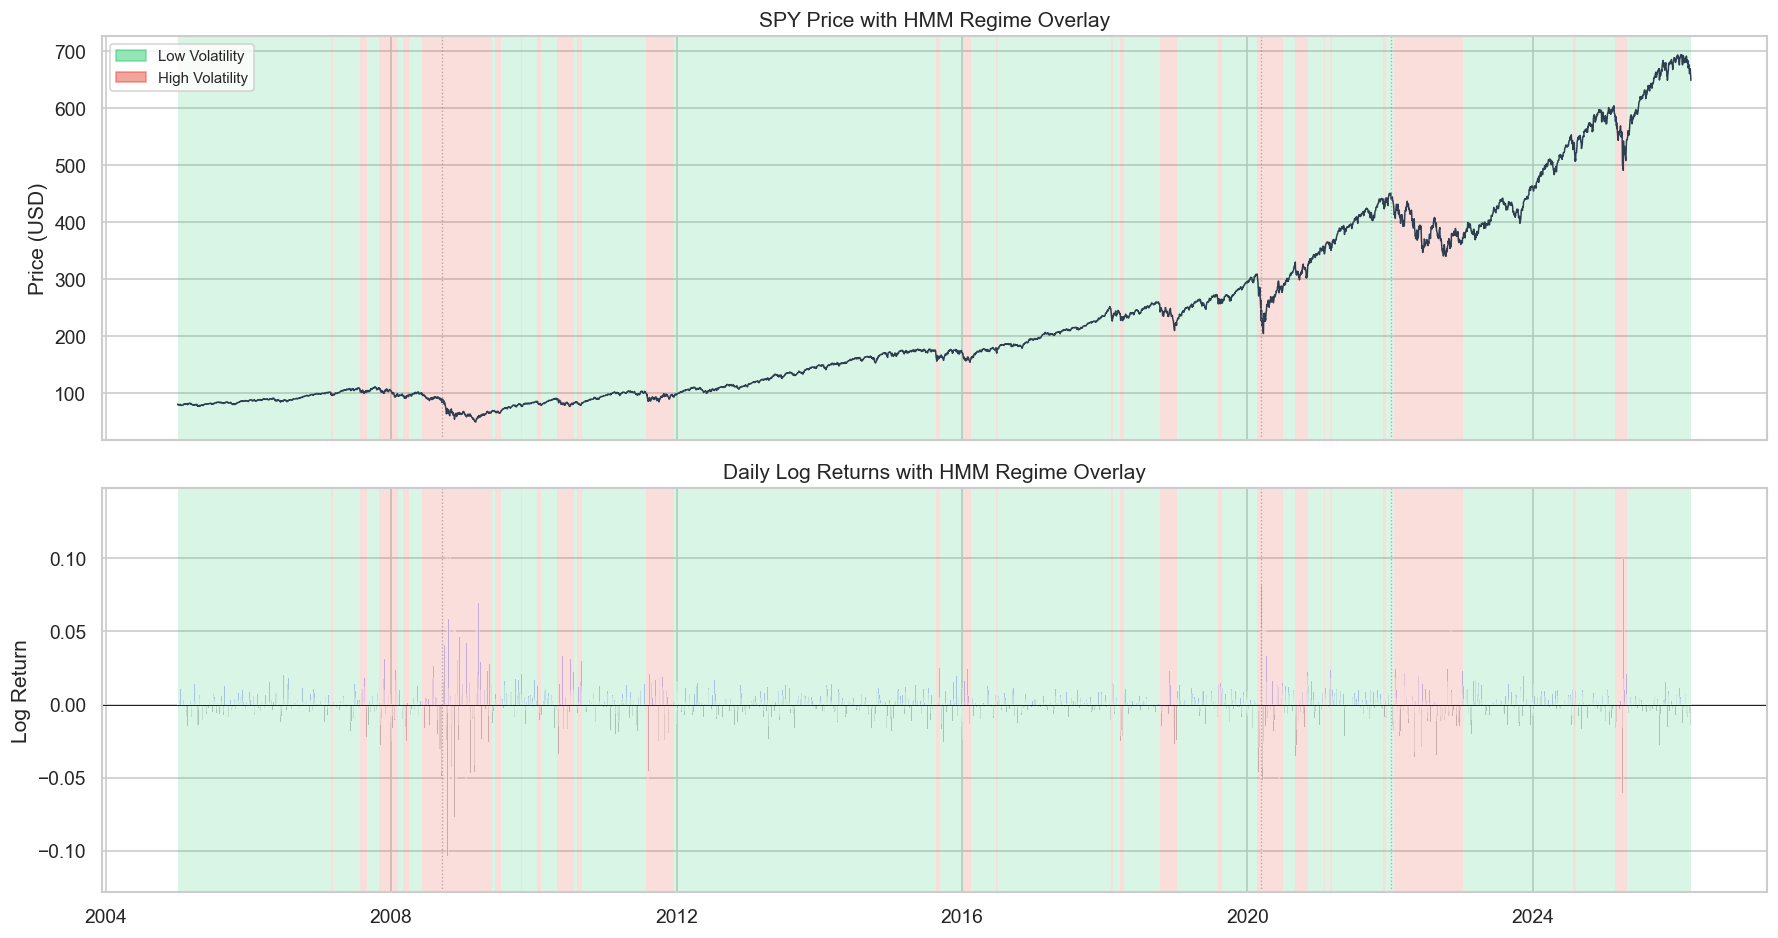

In [13]:
# Price chart with HMM regime shading
palette = {0: '#2ecc71', 1: '#e74c3c'}
regime_labels = {0: 'Low Volatility', 1: 'High Volatility'}

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Panel 1: Price
axes[0].plot(prices.index, prices.values, color='#2c3e50', linewidth=0.9, zorder=2)
axes[0].set_ylabel('Price (USD)')
axes[0].set_title('SPY Price with HMM Regime Overlay')

# Panel 2: Returns
axes[1].bar(log_returns.index, log_returns.values,
            color=np.where(log_returns.values >= 0, "#0505f3ff", "#0e010e"),
            width=1, alpha=0.6, zorder=1)
axes[1].set_ylabel('Log Return')
axes[1].set_title('Daily Log Returns with HMM Regime Overlay')
axes[1].axhline(0, color='black', linewidth=0.5)

# Shade regime periods on both panels
aligned = hmm_regimes.reindex(prices.index, method='ffill').dropna()
for ax in axes:
    current, start = None, None
    for date, regime in aligned.items():
        if regime != current:
            if current is not None:
                ax.axvspan(start, date, alpha=0.18, color=palette[int(current)], lw=0)
            current, start = regime, date
    if current is not None:
        ax.axvspan(start, aligned.index[-1], alpha=0.18,
                   color=palette[int(current)], lw=0)

# Legend
patches = [mpatches.Patch(color=palette[k], alpha=0.5, label=regime_labels[k])
           for k in sorted(palette)]
axes[0].legend(handles=patches, loc='upper left', fontsize=9)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Annotate known crisis periods
for ax in axes:
    for dt, label in [('2008-09-15', 'GFC'), ('2020-03-11', 'COVID'), ('2022-01-03', '2022 Bear')]:
        ax.axvline(pd.Timestamp(dt), color='grey', linestyle=':', alpha=0.6, linewidth=0.8)

fig.tight_layout()
plt.show()

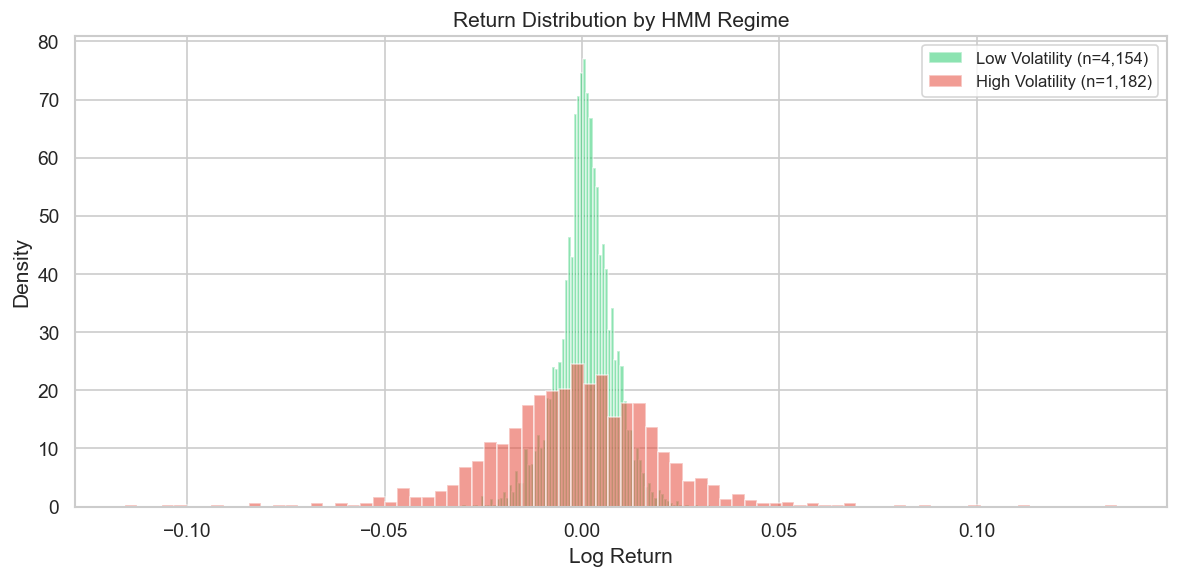

In [14]:
# ── Return distribution per regime ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for regime_id, color in palette.items():
    r = log_returns[hmm_regimes == regime_id]
    r.plot.hist(bins=80, alpha=0.55, color=color, ax=ax,
                label=f'{regime_labels[regime_id]} (n={len(r):,})', density=True)

ax.set_xlabel('Log Return')
ax.set_ylabel('Density')
ax.set_title('Return Distribution by HMM Regime')
ax.legend(fontsize=10)
fig.tight_layout()
plt.show()

---
## Method 2: Rolling KS Test — Distribution Shift over Time

The two-sample KS test compares a rolling **current** window against a **reference** window.  
A rising KS statistic (and falling p-value below 0.05) indicates the return distribution has shifted.

Fraction of time with significant distribution shift (p<0.05): 20.4%


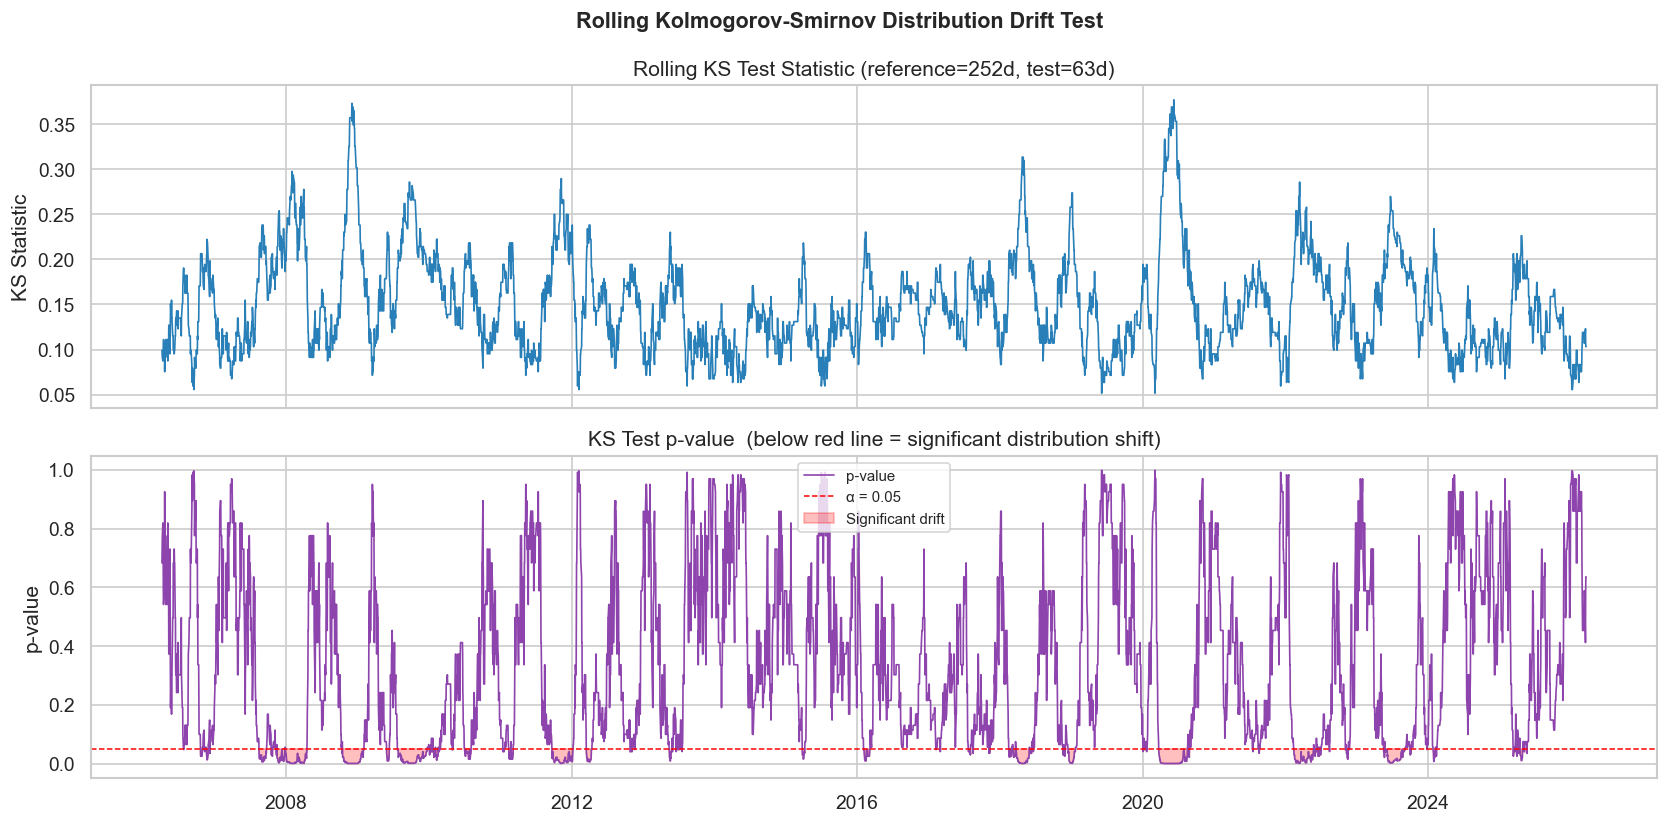

In [15]:
ks_df = rolling_ks_test(log_returns, ref_window=252, test_window=63)

drift_pct = 100 * ks_df['drift_flag'].mean()
print(f'Fraction of time with significant distribution shift (p<0.05): {drift_pct:.1f}%')

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(ks_df.index, ks_df['ks_stat'], color='#2980b9', linewidth=1.0)
axes[0].set_ylabel('KS Statistic')
axes[0].set_title('Rolling KS Test Statistic (reference=252d, test=63d)')

axes[1].plot(ks_df.index, ks_df['ks_pvalue'], color='#8e44ad', linewidth=1.0, label='p-value')
axes[1].axhline(0.05, color='red', linestyle='--', linewidth=0.9, label='α = 0.05')
axes[1].fill_between(ks_df.index, ks_df['ks_pvalue'].values, 0.05,
                     where=(ks_df['ks_pvalue'].values < 0.05),
                     alpha=0.25, color='red', label='Significant drift')
axes[1].set_ylabel('p-value')
axes[1].set_title('KS Test p-value  (below red line = significant distribution shift)')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Rolling Kolmogorov-Smirnov Distribution Drift Test', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

---
## Summary

| Method | Key finding |
|---|---|
| **HMM** | Cleanly separates calm (low-vol) and stress (high-vol) regimes; transition probabilities confirm high regime persistence |
| **Rolling KS** | Distribution drift is episodic and it is concentrated around crisis periods (not continuous) |

-> **Next:** Notebook 04 trains a predictive model and monitors its performance against these drift signals.